In [1]:
# import numpy as np 
import sys
import numpy as np
import pandas as pd
import datetime as datetime    
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import matplotlib as mpl
import re 
from scipy import signal #for filtering
import cmocean
import matplotlib.dates as mdates
print("Modules imported")

Modules imported


In [2]:
import re 
file="/global/scratch/users/jennaisrael/run_schism/run_test4sinks/station.in"
station_id =[]
with open(file) as f:
    f.readline()
    for station in range(int(f.readline())):
        line = f.readline()
        if '!' in line:
            station_id.append(line.split('!')[-1])
        else:
            station_id.append(None)
# print(station_id)

print(len(station_id))

stations = []
for sublist in station_id:
    match = re.search(r'"(.*?)"', sublist)
    if match:
        stations.append(match.group(1).strip())
    else :
        stations.append(sublist.replace("\n", "").strip())
print(len(set(stations)))


for i, station in enumerate(stations):
    print("%d == %s" % (i+1,station))

596
546
1 == San Joaquin at Antioch
2 == Mokelumne River at Benson's Ferry
3 == Cache Slough
4 == Cache Creek at Yolo
5 == Old River at Coney Island
6 == Clifton Court
7 == Discovery Bay at Indian Slough
8 == Doughty Cut above Grant Line Canal
9 == Sacramento River at Emmaton
10 == Sacramento River at Emmaton
11 == emm upper Emmaton
12 == emm lower Emmaton
13 == Farrar Park
14 == Grant Line Canal at Tracy Rd Bridge
15 == Green's Landing
16 == Harvey O Banks PP
17 == Holland Tract
18 == Harvey O Banks PP
19 == CCWD Old River near Discovery Bay
20 == CCWD Rock Slough PP
21 == Italian Slough Headwater near Byron
22 == Jersey Point
23 == Sacramento River at Mallard Island
24 == Sacramento River at Mallard Island
25 == Middle River at Howard Rd Bridge
26 == San Joaquin at Mossdale Bridge
27 == Middle River at Tracy Blvd
28 == Old River Barrier near DMC (Above)
29 == Old River below Dam
30 == Old River at Bacon Island
31 == Old River at Head
32 == Old River at Byron
33 == Prisoners Point
34 

In [3]:
file4='/global/scratch/users/jennaisrael/run_schism/run_30cor/outputs/staout_6'
file8='/global/scratch/users/jennaisrael/run_schism/run_31DCP/outputs/staout_6'
#file12='/global/scratch/users/jennaisrael/run_schism/run_test12sinks/outputs/staout_6'

In [4]:
#load the unfiltered data
columns = ['time']
stations_no = [str(i) for i in np.arange(1,597)]
columns = columns + stations_no

run13_r=pd.read_csv(file4, sep='\s+', names=columns,dtype=np.float32)
timedelta = [pd.Timedelta(i, unit = 's') for i in run13_r.time]
timestamp = [pd.to_datetime("08-14-2018 00:00:00") + i for i in timedelta]  
run13_r['time'] = timestamp
run13_r.set_index("time",inplace=True)
run14_r=pd.read_csv(file8, sep='\s+', names=columns,dtype=np.float32)
timedelta = [pd.Timedelta(i, unit = 's') for i in run14_r.time]
timestamp = [pd.to_datetime("08-14-2018 00:00:00") + i for i in timedelta] 
run14_r['time'] = timestamp
run14_r.set_index("time",inplace=True)
# run15_r=pd.read_csv(file12, sep='\s+', names=columns,dtype=np.float32)
# timedelta = [pd.Timedelta(i, unit = 's') for i in run15_r.time]
# timestamp = [pd.to_datetime("08-14-2018 00:00:00") + i for i in timedelta] 
# run15_r['time'] = timestamp
# run15_r.set_index("time",inplace=True)

(0, 0)
Max diff = 0.2145705223083496 PSU
Mean diff = -0.08097411692142487 PSU
(0, 1)
Max diff = 0.10929012298583984 PSU
Mean diff = -0.09993769973516464 PSU
(1, 0)
Max diff = 0.052029967308044434 PSU
Mean diff = 0.00013057996693532914 PSU
(1, 1)
Max diff = 0.014001965522766113 PSU
Mean diff = 0.0013135154731571674 PSU
(2, 0)
Max diff = 0.015344023704528809 PSU
Mean diff = 0.0011238425504416227 PSU
(2, 1)
Max diff = 0.10189098119735718 PSU
Mean diff = -0.007394581567496061 PSU


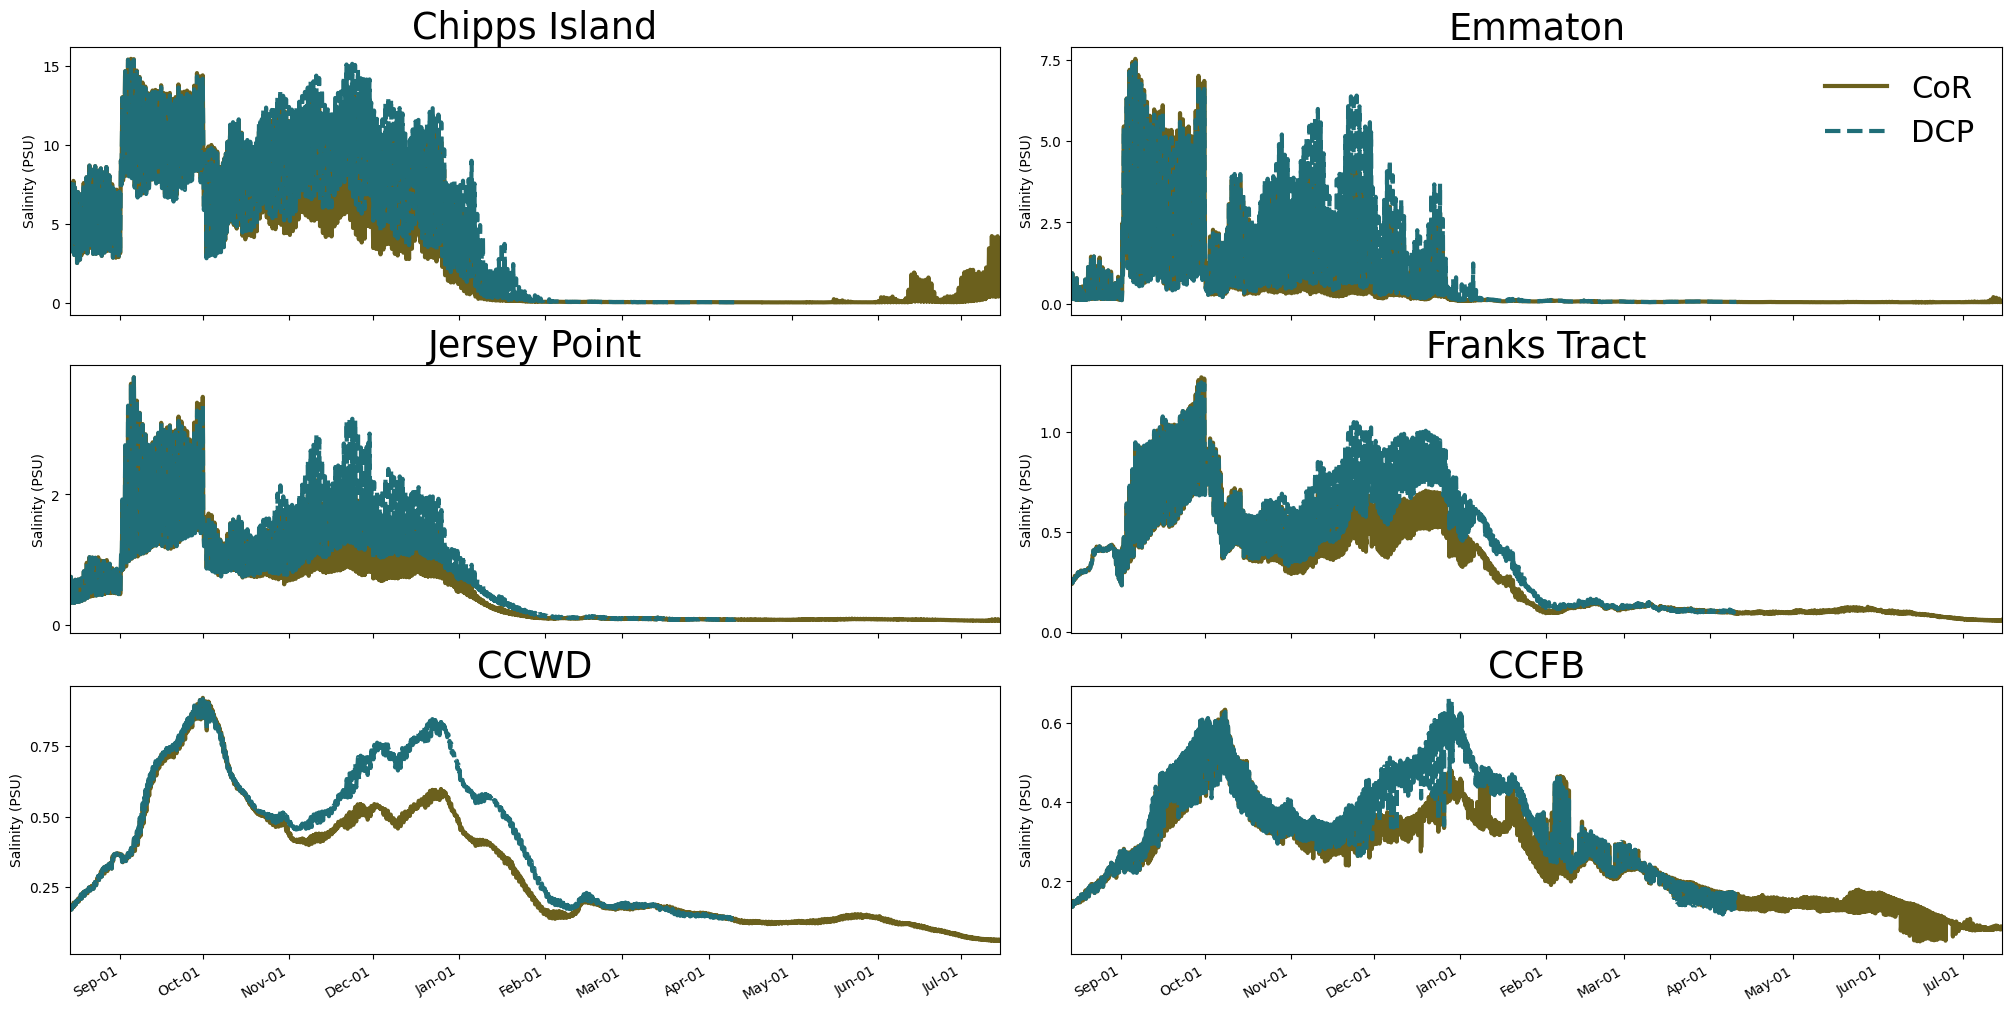

In [5]:
#station_indices=[226,22,12,168,6,203] 
#from Lily:
station_indices=[23,9,22,203,105,60]
fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        #ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        #ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(s)
    values1 = run13_r[str(idx)]
    values2 = run14_r[str(idx)]
    #values3 = run15_r[str(idx)]

    # #calculate the percent difference using the period when pumping occured
    dif=(values1.loc[pd.to_datetime("2018-10-3"):pd.to_datetime("2018-10-19")]-
            values2.loc[pd.to_datetime("2018-10-3"):pd.to_datetime("2018-10-19")])
    print('Max diff = '+str(np.max(dif))+ ' PSU')
    print('Mean diff = '+str(np.mean(dif))+' PSU')

    # perdif=dif/(0.5*(values1.loc[pd.to_datetime("2018-10-3"):pd.to_datetime("2018-10-19")]+
    #         values3.loc[pd.to_datetime("2018-10-3"):pd.to_datetime("2018-10-19")]))
    # print('Max per diff = '+str(100*np.max(perdif))+ ' %')
    # print('Mean per diff = '+str(100*np.mean(perdif))+' %')
          
    ax[s].plot(values1, label = 'CoR', linewidth=3, alpha =1, color=cmocean.cm.tarn(1/6))
    ax[s].plot(values2, label = 'DCP', linewidth=3, alpha =1,linestyle='--', color=cmocean.cm.tarn(10/12))
    #ax[s].plot(values3, label = '12 sinks', linewidth=3, alpha =1,linestyle=(0,(1,1)), color=cmocean.cm.tarn(2/6))
    #ax[s].set_title(stations[idx-1]) #this list is zero indexed
    ax[s].set_title(tstring)
    #ax[s].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
    ax[s].set_xlim(pd.to_datetime("2018-08-14"),pd.to_datetime("2019-7-15"))
    ax[s].set_ylabel('Salinity (PSU)')
    # Rotates and right-aligns the x labels so they don't crowd each other.

    
#ax.plot(data1.time,np.ones_like(values1)*std,linewidth=2, alpha =0.7,linestyle='--',color='k',label='Compliance')

#leg = ax.legend()
#print(ax)
#ax.set_xlim(data1.time.iloc[52000], data3.time.iloc[-1]) #July 1 to end
# ax.grid(which='major', color='b', linestyle='-')
#ax.set_title("Salinity from baroclinic run")
#ax[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d-%Y'))
ax[0,1].legend(frameon=False)
ax[2,0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,0].xaxis.get_major_locator()))
ax[2,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,0].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax[2,1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,1].xaxis.get_major_locator()))
ax[2,1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,1].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

plt.show()
#fig.savefig('six_stations_timeseries_legend_2_endfeb.png')

(0, 0)
(0, 1)
(1, 0)
(1, 1)
(2, 0)
(2, 1)


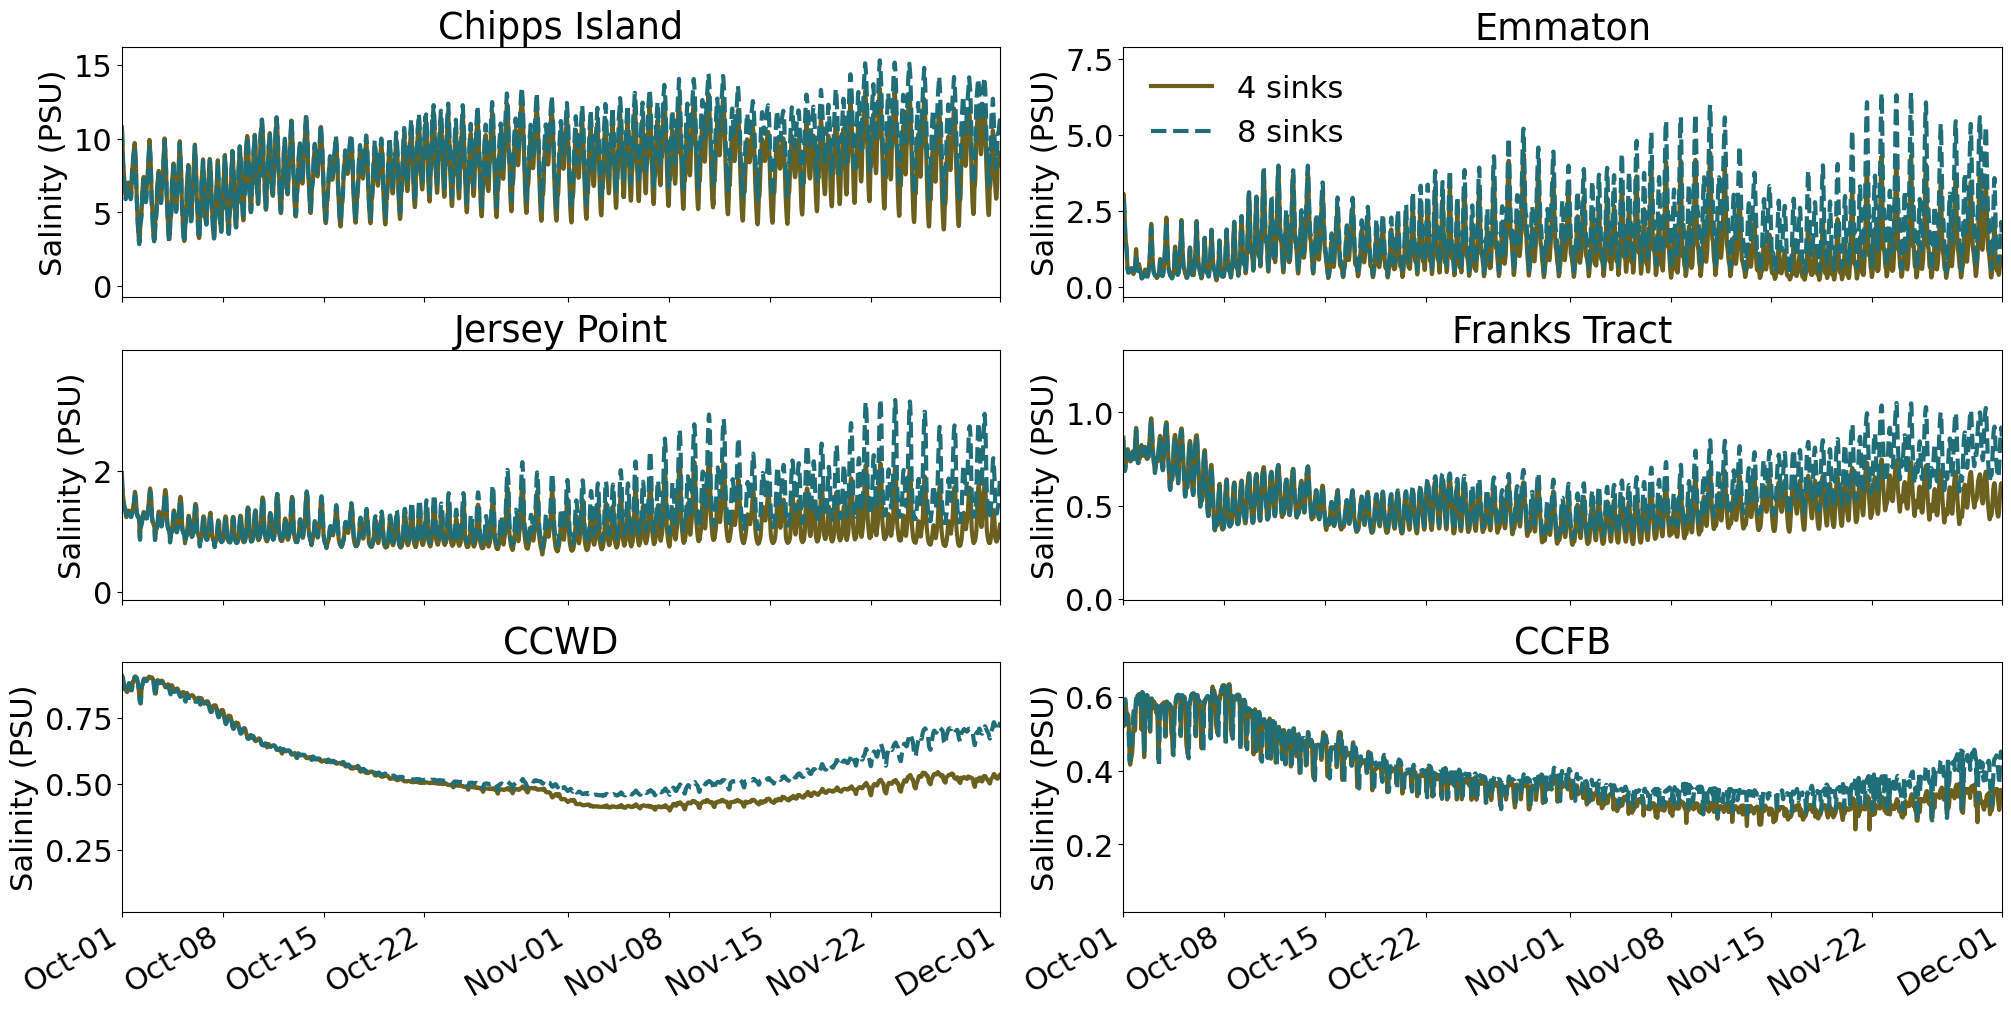

In [6]:
#station_indices=[226,22,12,168,6,203] 
#from Lily:
station_indices=[23,9,22,203,105,60]
fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        #ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        #ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(s)
    values1 = run13_r[str(idx)]
    values2 = run14_r[str(idx)]
    #values3 = run15_r[str(idx)]

    # #calculate the percent difference using the period when pumping occured
    # dif=(values1.loc[pd.to_datetime("2018-10-3"):pd.to_datetime("2018-10-19")]-
    #         values3.loc[pd.to_datetime("2018-10-3"):pd.to_datetime("2018-10-19")])
    # print('Max diff = '+str(np.max(dif))+ ' PSU')
    # print('Mean diff = '+str(np.mean(dif))+' PSU')

    # perdif=dif/(0.5*(values1.loc[pd.to_datetime("2018-10-3"):pd.to_datetime("2018-10-19")]+
    #         values3.loc[pd.to_datetime("2018-10-3"):pd.to_datetime("2018-10-19")]))
    # print('Max per diff = '+str(100*np.max(perdif))+ ' %')
    # print('Mean per diff = '+str(100*np.mean(perdif))+' %')
          
    ax[s].plot(values1, label = '4 sinks', linewidth=3, alpha =1, color=cmocean.cm.tarn(1/6))
    ax[s].plot(values2, label = '8 sinks', linewidth=3, alpha =1,linestyle='--', color=cmocean.cm.tarn(10/12))
    #ax[s].plot(values3, label = '12 sinks', linewidth=3, alpha =1,linestyle=(0,(1,1)), color=cmocean.cm.tarn(2/6))
    #ax[s].set_title(stations[idx-1]) #this list is zero indexed
    ax[s].set_title(tstring)
    #ax[s].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
    ax[s].set_xlim(pd.to_datetime("2018-10-01"),pd.to_datetime("2018-12-01"))
    ax[s].set_ylabel('Salinity (PSU)')
    # Rotates and right-aligns the x labels so they don't crowd each other.

    
#ax.plot(data1.time,np.ones_like(values1)*std,linewidth=2, alpha =0.7,linestyle='--',color='k',label='Compliance')

#leg = ax.legend()
#print(ax)
#ax.set_xlim(data1.time.iloc[52000], data3.time.iloc[-1]) #July 1 to end
# ax.grid(which='major', color='b', linestyle='-')
#ax.set_title("Salinity from baroclinic run")
#ax[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d-%Y'))
ax[0,1].legend(frameon=False)
ax[2,0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,0].xaxis.get_major_locator()))
ax[2,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,0].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax[2,1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,1].xaxis.get_major_locator()))
ax[2,1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,1].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

plt.show()
#fig.savefig('six_stations_timeseries_legend_2_endfeb.png')